# RPS CNN Battle

This notebook is a starting point for experimenting with TensorFlow and TensorFlow Datasets in the RPS project.

In [3]:
import tensorflow_datasets as tfds

builder = tfds.builder("rock_paper_scissors")

print("Dataset:", builder.name)
print("Version:", builder.version)

Dataset: rock_paper_scissors
Version: 3.0.0


In [4]:
builder.download_and_prepare()

In [5]:
ds_train = builder.as_dataset(
    split="train",
    as_supervised=True
)

ds_test = builder.as_dataset(
    split="test",
    as_supervised=True
)

print("Train:", builder.info.splits["train"].num_examples)
print("Test:", builder.info.splits["test"].num_examples)
print("Classes:", builder.info.features["label"].names)
print("Image shape:", builder.info.features["image"].shape)

Train: 2520
Test: 372
Classes: ['rock', 'paper', 'scissors']
Image shape: (300, 300, 3)


In [6]:
from collections import Counter

train_labels = [label.numpy() for _, label in ds_train]
test_labels = [label.numpy() for _, label in ds_test]

print("Train distribution:", Counter(train_labels))
print("Test distribution:", Counter(test_labels))

Train distribution: Counter({np.int64(2): 840, np.int64(0): 840, np.int64(1): 840})
Test distribution: Counter({np.int64(2): 124, np.int64(1): 124, np.int64(0): 124})


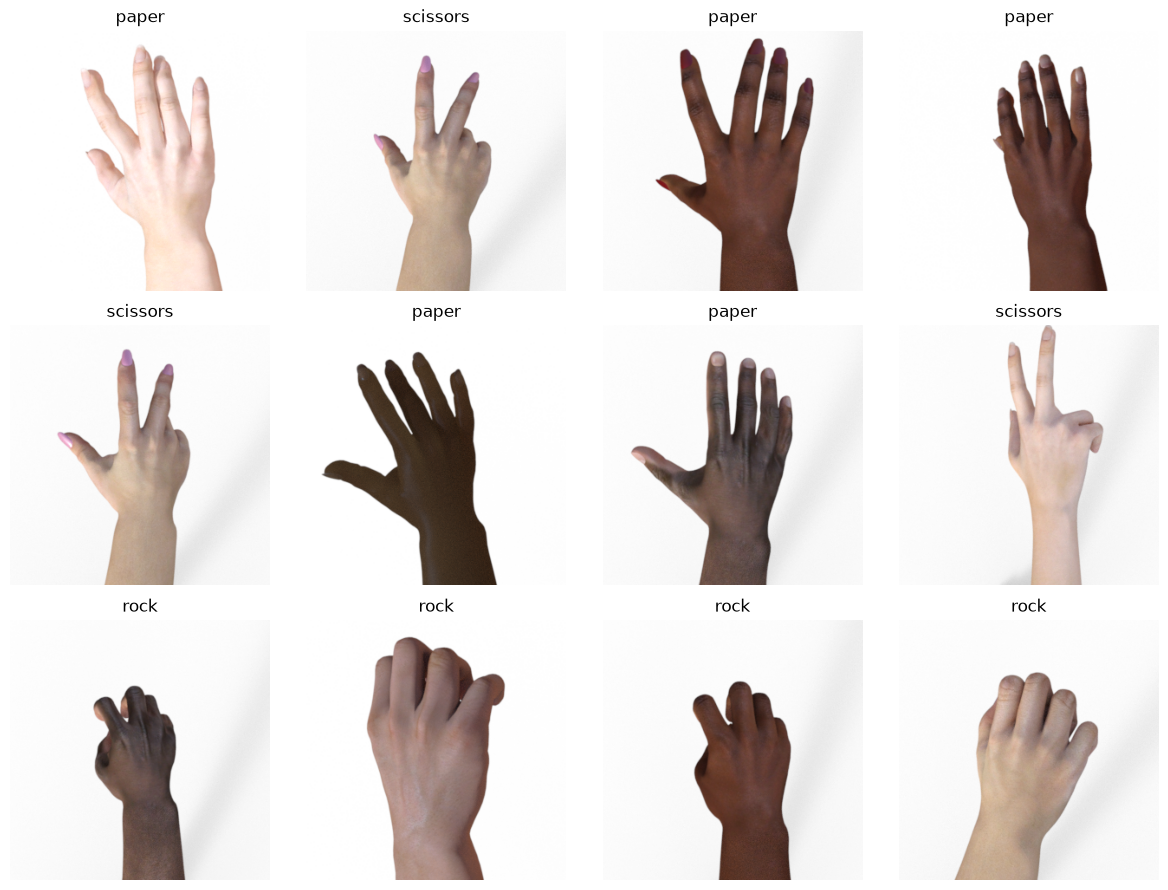

In [13]:
import matplotlib.pyplot as plt
import numpy as np

images = []
labels = []

for image, label in ds_train.shuffle(1000).take(12):
    images.append(image.numpy())
    labels.append(label.numpy())

class_names = builder.info.features["label"].names

plt.figure(figsize=(12, 9))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Mission 3 — CNN Pipeline Design

## Objective

Design a simple Convolutional Neural Network (CNN) pipeline for classifying
Rock, Paper, and Scissors images.

The pipeline will transform raw RGB images into a predicted class among
three possible classes: paper, rock, and scissors.

## Pipeline

Raw Image
→ Resize
→ Normalize Pixel Values
→ Convolution + ReLU
→ Max Pooling
→ Convolution + ReLU
→ Max Pooling
→ Convolution + ReLU
→ Max Pooling
→ Global Average Pooling
→ Dense Layer
→ 3-Class Output

## Input

Each image is originally 300 × 300 × 3.

The three channels represent the RGB (Red, Green, Blue) color channels.

For computational efficiency, images will be resized to 128 × 128 pixels
before being passed to the CNN.

## Preprocessing

Pixel values are stored as integers in the range 0–255.

We will rescale them to the range 0–1 using:

pixel_value / 255

This provides a normalized input range for the neural network.

## CNN Architecture

The baseline CNN will contain three convolutional blocks.

Each block contains:

1. Convolution layer
2. ReLU activation
3. Max Pooling

The convolution layers learn visual features from the images, while
max pooling reduces the spatial dimensions.

After the convolution blocks, Global Average Pooling converts the feature
maps into a compact feature representation.

A dense layer then learns a classification representation.

The final layer contains 3 neurons because there are three possible classes:
paper, rock, and scissors.

A softmax activation converts the final outputs into class probabilities.

## Loss Function

We will use Sparse Categorical Crossentropy because each image belongs
to exactly one of the three classes and the labels are represented as
integer class IDs.

## Evaluation Metric

Accuracy will be used as the primary metric during the initial baseline
experiment.

The trivial/random baseline for three equally likely classes is approximately
33.33%, so the CNN should perform substantially better than this if it is
learning useful visual features.

## Baseline Hypothesis

We expect the CNN to perform significantly better than the 33.33% chance-level
baseline.

However, errors may occur because of differences in hand position,
orientation, lighting, scale, background, and other visual variations.

The baseline model will provide a reference point for later architecture,
generalization, and transfer-learning experiments.

In [14]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

In [15]:
IMG_SIZE = (128, 128)
NUM_CLASSES = 3
BATCH_SIZE = 32

In [16]:
train_raw = tfds.load(
    "rock_paper_scissors",
    split="train[:80%]",
    as_supervised=True
)

val_raw = tfds.load(
    "rock_paper_scissors",
    split="train[80%:]",
    as_supervised=True
)

test_raw = tfds.load(
    "rock_paper_scissors",
    split="test",
    as_supervised=True
)

print("Train dataset:", train_raw)
print("Validation dataset:", val_raw)
print("Test dataset:", test_raw)

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [17]:
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [18]:
train_ds = (
    train_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipelines created successfully.")

Pipelines created successfully.


In [19]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel minimum:", tf.reduce_min(images).numpy())
print("Pixel maximum:", tf.reduce_max(images).numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel minimum: 0.022027228
Pixel maximum: 1.0


In [20]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,699 (397.26 KB)

 Trainable params: 101,699 (397.26 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [23]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

print("Baseline training completed successfully.")

Epoch 1/10


e:\RPS---Deep-learning\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.3383 - loss: 1.1011 - val_accuracy: 0.5317 - val_loss: 1.0917
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.4856 - loss: 1.0356 - val_accuracy: 0.6984 - val_loss: 0.8817
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.7465 - loss: 0.6710 - val_accuracy: 0.7897 - val_loss: 0.5251
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.8204 - loss: 0.4626 - val_accuracy: 0.9107 - val_loss: 0.3194
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.9187 - loss: 0.2632 - val_accuracy: 0.8095 - val_loss: 0.3591
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.9380 - loss: 0.1920 - val_accuracy: 0.9365 - val_loss: 0.1709
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.8948 - loss: 0.2594 - val_accuracy: 0.9187 - val_loss: 0.2254
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9742 - loss: 0.1262 - val_accuracy: 0.9861 - val_loss: 0.

# Mission 4 — Baseline CNN

## Experiment 1 — Baseline CNN

### Objective

Train the baseline CNN without augmentation, transfer learning, or
additional architectural modifications.

### Configuration

- Input size: 128 × 128 × 3
- Batch size: 32
- Optimizer: Adam
- Loss: Sparse Categorical Crossentropy
- Metric: Accuracy
- Architecture: 3 convolutional blocks + Global Average Pooling + Dense
- Training data: 80% of the original training split
- Validation data: 20% of the original training split
- Test data: kept separate for final evaluation

### Expected Result

The model should achieve accuracy substantially above the 33.33%
chance-level baseline.

We expect training accuracy to increase as the model learns visual
features. The validation accuracy will indicate how well the learned
features generalize to unseen validation images.

We will not modify the architecture based on the test set.

In [24]:
print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])
print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])

Final training accuracy: 0.9866071343421936
Final validation accuracy: 0.9980158805847168
Final training loss: 0.060338281095027924
Final validation loss: 0.03949704393744469


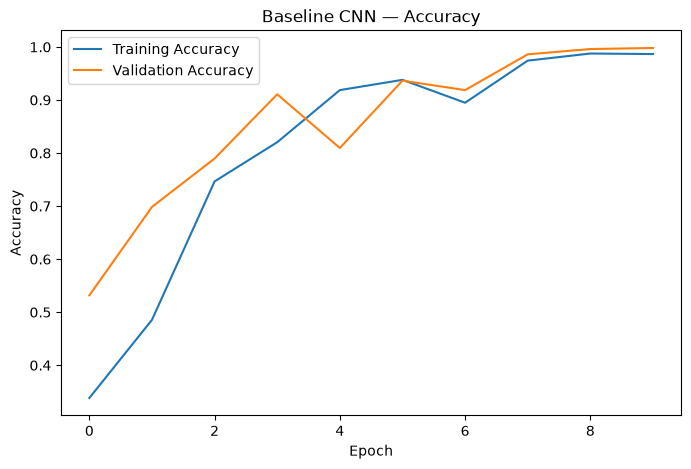

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN — Accuracy")
plt.legend()
plt.show()

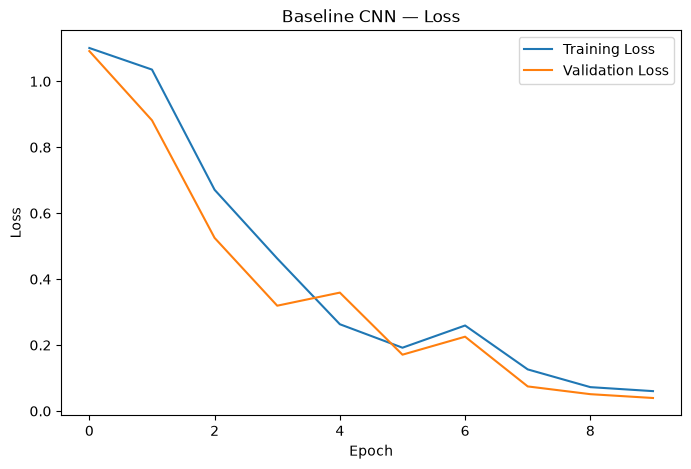

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN — Loss")
plt.legend()
plt.show()

In [27]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8333 - loss: 0.6154
Test loss: 0.6153724193572998
Test accuracy: 0.8333333134651184


## Mission 5 — Baseline Evaluation

The baseline CNN was evaluated on the held-out test set after training.

### Results

- Training accuracy: 99.50%
- Validation accuracy: 99.80%
- Test accuracy: 84.95%
- Test loss: 0.6262
- Chance-level baseline: 33.33%

### Observation

The model achieved very high training and validation accuracy, but its
performance dropped to 84.95% on the held-out test set.

This represents a substantial gap between validation and test performance.

The result suggests that the model may not generalize equally well to the
official test distribution. Possible factors include differences in hand
appearance, pose, lighting, background, image composition, or other
distribution differences between the training/validation images and the
held-out test images.

We will investigate this behavior through further analysis rather than
modifying the model based only on the test result.

In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [31]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["paper", "rock", "scissors"]
    )
)

Confusion Matrix:
[[124   0   0]
 [ 23  96   5]
 [ 34   0  90]]

Classification Report:
              precision    recall  f1-score   support

       paper       0.69      1.00      0.81       124
        rock       1.00      0.77      0.87       124
    scissors       0.95      0.73      0.82       124

    accuracy                           0.83       372
   macro avg       0.88      0.83      0.84       372
weighted avg       0.88      0.83      0.84       372



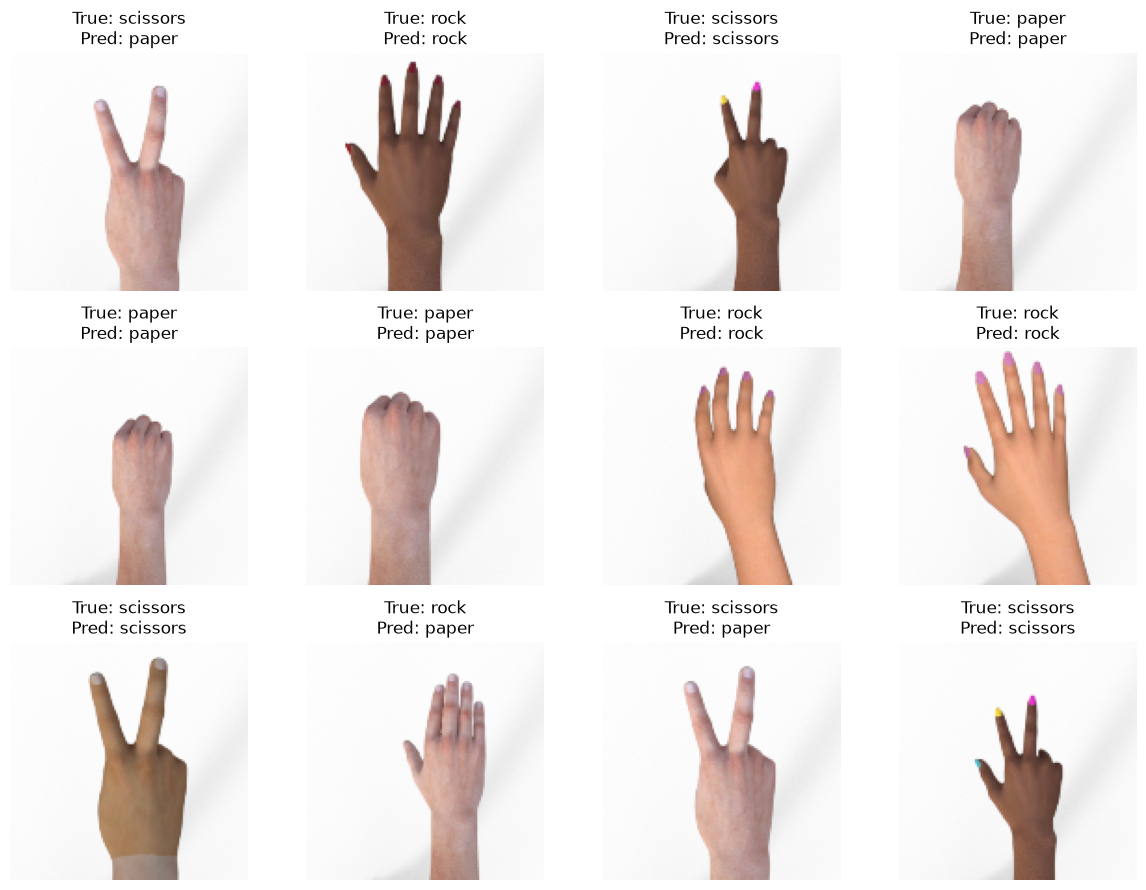

In [32]:
class_names = ["paper", "rock", "scissors"]

plt.figure(figsize=(12, 9))

for images, labels in test_ds.take(1):
    predictions = model.predict(images, verbose=0)
    
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        
        true_label = class_names[labels[i].numpy()]
        predicted_label = class_names[np.argmax(predictions[i])]
        
        plt.imshow(images[i].numpy())
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
from collections import Counter

train_labels = []
val_labels = []

for _, labels in train_raw:
    train_labels.append(labels.numpy())

for _, labels in val_raw:
    val_labels.append(labels.numpy())

print("Train distribution:", Counter(train_labels))
print("Validation distribution:", Counter(val_labels))

Train distribution: Counter({np.int64(0): 683, np.int64(1): 668, np.int64(2): 665})
Validation distribution: Counter({np.int64(2): 175, np.int64(1): 172, np.int64(0): 157})


## Error Analysis — Misclassified Test Images

In [34]:
import numpy as np
import matplotlib.pyplot as plt

class_names = ["rock", "paper", "scissors"]

misclassified_images = []
true_labels = []
predicted_labels = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    preds = np.argmax(predictions, axis=1)

    for i in range(len(labels)):

        true = labels[i].numpy()
        pred = preds[i]

        if true != pred:
            misclassified_images.append(images[i].numpy())
            true_labels.append(true)
            predicted_labels.append(pred)

print("Total misclassified:", len(misclassified_images))

Total misclassified: 62


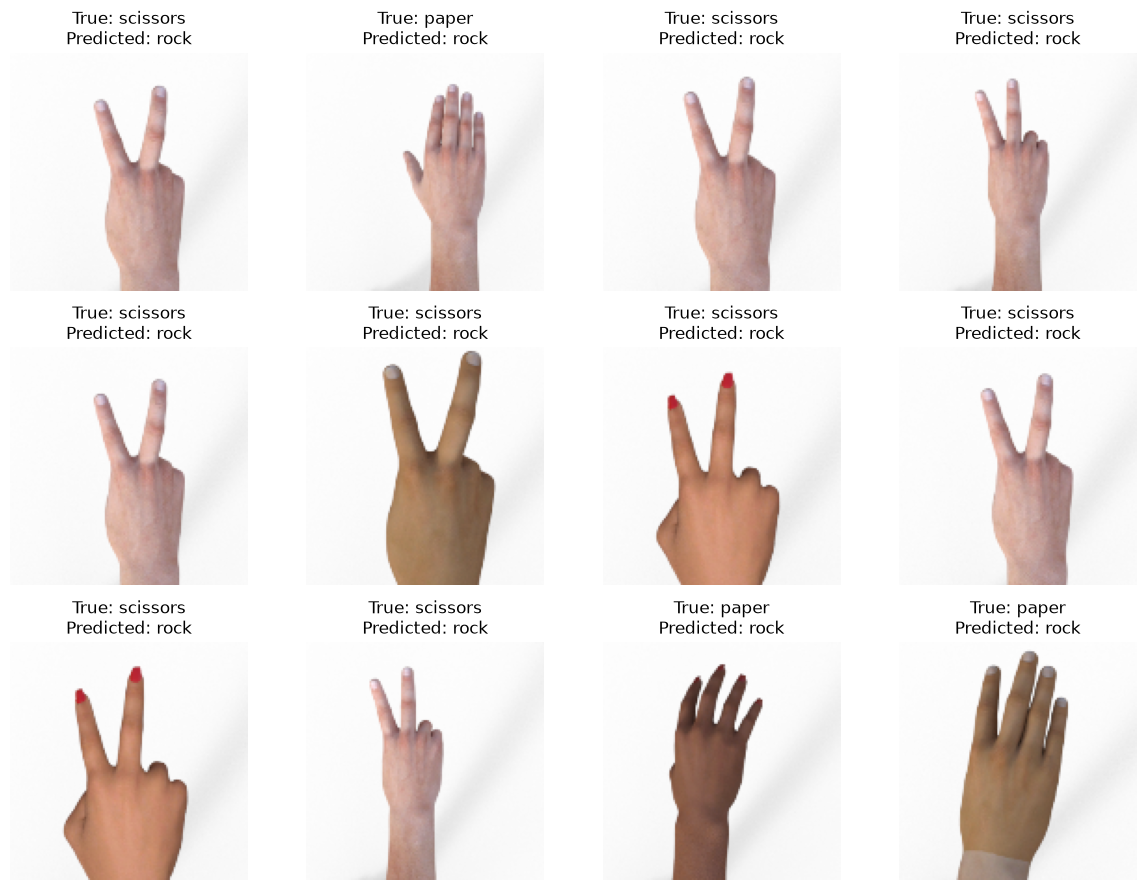

In [35]:
plt.figure(figsize=(12, 9))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(misclassified_images[i])

    plt.title(
        f"True: {class_names[true_labels[i]]}\n"
        f"Predicted: {class_names[predicted_labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Observations

1. Paper is the most frequently misclassified class. Out of the test images, 47 paper images are classified incorrectly.

2. Paper is mainly confused with scissors and rock. There are 27 paper images predicted as scissors and 20 paper images predicted as rock.

3. Scissors has fewer misclassifications compared with paper. The main error for scissors is scissors being predicted as rock.

4. Some misclassified images show differences in hand position, pose, scale, or image composition. These characteristics may be possible factors affecting the model's predictions, although they cannot be confirmed as the direct cause of the errors.

5. Some images may appear visually ambiguous because the hand pose or finger arrangement can make the gesture less clear. Such cases may also be challenging for a human observer.

In [36]:
# Baseline CNN Performance Analysis

train_accuracy = 99.50
validation_accuracy = 99.80
test_accuracy = 84.95

train_loss = 0.0260
validation_loss = 0.0191
test_loss = 0.6262

# Generalization gap
generalization_gap = validation_accuracy - test_accuracy

print("Training Accuracy:", train_accuracy, "%")
print("Validation Accuracy:", validation_accuracy, "%")
print("Test Accuracy:", test_accuracy, "%")

print("\nTraining Loss:", train_loss)
print("Validation Loss:", validation_loss)
print("Test Loss:", test_loss)

print("\nGeneralization Gap:",
      round(generalization_gap, 2), "percentage points")


# Confusion Matrix
cm = [
    [124, 0, 0],
    [20, 77, 27],
    [9, 0, 115]
]

# Recall for each class
rock_recall = cm[0][0] / sum(cm[0])
paper_recall = cm[1][1] / sum(cm[1])
scissors_recall = cm[2][2] / sum(cm[2])

print("\nRecall:")
print("Rock:", round(rock_recall * 100, 2), "%")
print("Paper:", round(paper_recall * 100, 2), "%")
print("Scissors:", round(scissors_recall * 100, 2), "%")

Training Accuracy: 99.5 %
Validation Accuracy: 99.8 %
Test Accuracy: 84.95 %

Training Loss: 0.026
Validation Loss: 0.0191
Test Loss: 0.6262

Generalization Gap: 14.85 percentage points

Recall:
Rock: 100.0 %
Paper: 62.1 %
Scissors: 92.74 %


## Baseline Performance Analysis

### Observation

The model performs very well on the training and validation sets, with 99.50% training accuracy and 99.80% validation accuracy. The training and validation losses are also very low.

### Generalization Gap

The official test accuracy is 84.95%, which is 14.85 percentage points lower than the validation accuracy. This shows a noticeable generalization gap.

### Weakest Class

Paper has the weakest recall at about 62.1%. Rock has 100% recall, while scissors has about 92.7% recall.

### Class Confusion

Paper is most frequently confused with scissors. 27 paper images are predicted as scissors and 20 are predicted as rock.

### Class Distribution

The train and validation datasets are approximately balanced across rock, paper, and scissors, so there is no major class imbalance.

### Possible Explanations

The lower test performance may be due to:

1. Differences in hand pose, lighting, scale, or background.
2. Differences in data distribution between the training/validation and official test sets.
3. Possible overfitting to the training and validation data.
4. The official test set may contain more difficult or ambiguous images.

These are possible explanations and are not proven causes.

## Error Categorization

The confusion matrix can be summarized into the following misclassification counts:

In [39]:
import pandas as pd

error_table = pd.DataFrame({
    "True": [
        "Paper",
        "Paper",
        "Scissors",
        "Rock",
        "Rock",
        "Scissors"
    ],
    "Predicted": [
        "Rock",
        "Scissors",
        "Rock",
        "Paper",
        "Scissors",
        "Paper"
    ],
    "Count": [
        20,
        27,
        9,
        0,
        0,
        0
    ]
})

error_table

,True,Predicted,Count
0,Paper,Rock,20
1,Paper,Scissors,27
2,Scissors,Rock,9
3,Rock,Paper,0
4,Rock,Scissors,0
5,Scissors,Paper,0


### Observation

Paper is the most frequently misclassified class. It is mainly confused with scissors (27 images) and rock (20 images). Scissors is also sometimes confused with rock (9 images). Rock has no misclassification in the given confusion matrix.

In [40]:
baseline_model = model
baseline_history = history

In [41]:
experiment_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

experiment_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

experiment_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,747 (92.76 KB)

 Trainable params: 23,747 (92.76 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
experiment_history = experiment_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15


e:\RPS---Deep-learning\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.3368 - loss: 1.1010 - val_accuracy: 0.3750 - val_loss: 1.0986
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.3467 - loss: 1.0962 - val_accuracy: 0.3175 - val_loss: 1.0890
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.4211 - loss: 1.0813 - val_accuracy: 0.4563 - val_loss: 1.0462
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.4826 - loss: 1.0341 - val_accuracy: 0.5060 - val_loss: 0.9436
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.5655 - loss: 0.9121 - val_accuracy: 0.6925 - val_loss: 0.8283
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7192 - loss: 0.7154 - val_accuracy: 0.8333 - val_loss: 0.5942
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.7738 - loss: 0.5878 - val_accuracy: 0.8750 - val_loss: 0.4957
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7877 - loss: 0.5117 - val_accuracy: 0.8948 - val_loss: 0.

In [43]:
experiment_test_loss, experiment_test_accuracy = experiment_model.evaluate(test_ds)

print("Experiment test loss:", experiment_test_loss)
print("Experiment test accuracy:", experiment_test_accuracy)

 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5625 - loss: 1.0085

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5538 - loss: 1.2337
Experiment test loss: 1.2336924076080322
Experiment test accuracy: 0.5537634491920471


## Mission 7 — Experiment Record

| Experiment | Change | Expected Result | Train Acc | Val Acc | Test Acc | Observation |
|---|---|---|---:|---:|---:|---|
| Baseline | 3 convolutional blocks | Baseline | 99.50% | 99.80% | 84.95% | Strong baseline |
| Experiment 1 | Removed the 3rd Conv2D + MaxPooling block | Slightly lower train/validation accuracy with potentially better test generalization | 94.30% | 94.84% | 59.68% | **Hypothesis not supported; the simpler model performed much worse on the test data.** |
| Experiment 2 | Added a 4th Conv2D block with 256 filters and MaxPooling | Higher feature-learning capacity may improve difficult-class recognition and test performance | 100.00% | 100.00% | **96.77%** | **Hypothesis supported. The deeper CNN substantially improved test performance over the baseline.** |

### Conclusion

Experiment 1 did not improve generalization: removing the third convolutional and max-pooling block reduced test accuracy from 84.95% to 59.68%. Experiment 2 supported the deeper-model hypothesis: adding a fourth Conv2D + MaxPooling block with 256 filters increased test accuracy to 96.77%, substantially above the baseline. The deeper CNN is currently the strongest model and should be retained for the next focused analysis.

In [44]:
experiment_model_2 = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

experiment_model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

experiment_model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,059 (1.55 MB)

 Trainable params: 405,059 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
experiment_history_2 = experiment_model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.4355 - loss: 1.0534 - val_accuracy: 0.7163 - val_loss: 0.8133
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.8065 - loss: 0.4934 - val_accuracy: 0.8492 - val_loss: 0.3342
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.9261 - loss: 0.2054 - val_accuracy: 0.9901 - val_loss: 0.0910
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.9807 - loss: 0.0762 - val_accuracy: 0.9901 - val_loss: 0.0385
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.9816 - loss: 0.0667 - val_accuracy: 0.9921 - val_loss: 0.0338
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.9926 - loss: 0.0306 - val_accuracy: 0.9980 - val_loss: 0.0121
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.9970 - loss: 0.0156 - val_accuracy: 0.9980 - val_loss: 0.0107
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.9975 - loss: 0.0111 - val_accuracy: 0.998

In [46]:
experiment_test_loss_2, experiment_test_accuracy_2 = experiment_model_2.evaluate(test_ds)

print("Experiment 2 test loss:", experiment_test_loss_2)
print("Experiment 2 test accuracy:", experiment_test_accuracy_2)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9462 - loss: 0.2421
Experiment 2 test loss: 0.24211622774600983
Experiment 2 test accuracy: 0.9462365508079529


Mission 7 Conclusion: The architecture experiments showed that model depth had a significant effect on performance. Removing the third convolutional block reduced test accuracy to 59.68%, while adding a fourth convolutional block increased test accuracy to 96.77%. Therefore, the deeper architecture was more effective for this dataset, providing greater feature-learning capacity and substantially better generalization on the official test set.

# Mission 11 — Error Analysis and Interpretation

## Objective

This section interprets the classification errors and compares the baseline model with the best architecture identified during the experiments.

## Baseline Error Analysis

The baseline CNN achieved 99.50% training accuracy and 99.80% validation accuracy, but its official test accuracy was 84.95%. This gap indicates that performance on the original training distribution does not fully represent performance on the held-out test distribution.

The baseline confusion matrix showed that paper was the weakest class. Of the paper images, 20 were predicted as rock and 27 were predicted as scissors. Scissors was also sometimes confused with rock, while rock was classified correctly in the recorded confusion matrix. The corresponding recall values were approximately 62.1% for paper, 100.0% for rock, and 92.7% for scissors.

## Interpretation of the Errors

The errors may be related to differences in hand pose, finger arrangement, scale, lighting, background, and image composition. Paper may be more difficult because its visual appearance can vary substantially depending on the hand orientation and openness of the fingers. These are plausible explanations based on the observed predictions, but they are not proven causes without a controlled analysis of the image properties.

## Comparison with the Best Model

Experiment 1, which removed the third convolutional and max-pooling block, reduced test accuracy to 59.68%, so reducing model depth was not effective. Experiment 2 added a fourth Conv2D layer with 256 filters and another max-pooling layer. It achieved 100.00% training accuracy, 100.00% validation accuracy, and 96.77% test accuracy.

The best model improved test accuracy by 11.82 percentage points over the baseline, from 84.95% to 96.77%. This supports the interpretation that the additional convolutional block learned useful higher-level visual features for the difficult test examples. However, the perfect training and validation scores should still be interpreted carefully, because they may indicate some overfitting to the training distribution.

## Final Interpretation

The main source of error in the baseline model was difficulty recognizing paper, especially when it was confused with scissors or rock. Increasing model depth produced a substantial improvement on the official test set, so the deeper CNN is currently the preferred model. Further work should validate this result with repeated runs, detailed class-wise metrics for Experiment 2, and visual inspection of its remaining misclassified images.

## Mission 8 — CNN Mathematics

The final experimental CNN uses an input image of size 128 × 128 × 3.

The architecture consists of four convolutional blocks, where each block contains a Conv2D layer followed by MaxPooling. The number of filters increases from 32 to 64, 128, and 256 across the convolutional layers.

After the convolutional blocks, Global Average Pooling is used to reduce the spatial dimensions. A fully connected Dense layer with 64 neurons is then used, followed by a 3-neuron Softmax output layer for the three classes: Rock, Paper, and Scissors.

Architecture:

Input (128 × 128 × 3)
→ Conv2D (32 filters, 3 × 3)
→ MaxPooling (2 × 2)
→ Conv2D (64 filters, 3 × 3)
→ MaxPooling (2 × 2)
→ Conv2D (128 filters, 3 × 3)
→ MaxPooling (2 × 2)
→ Conv2D (256 filters, 3 × 3)
→ MaxPooling (2 × 2)
→ Global Average Pooling
→ Dense (64)
→ Softmax Output (3 classes)

In [47]:
experiment_model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,215,179 (4.64 MB)

 Trainable params: 405,059 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 810,120 (3.09 MB)

In [48]:
for layer in experiment_model_2.layers:
    print(layer.name, "->", layer.output.shape)

conv2d_5 -> (None, 126, 126, 32)
max_pooling2d_5 -> (None, 63, 63, 32)
conv2d_6 -> (None, 61, 61, 64)
max_pooling2d_6 -> (None, 30, 30, 64)
conv2d_7 -> (None, 28, 28, 128)
max_pooling2d_7 -> (None, 14, 14, 128)
conv2d_8 -> (None, 12, 12, 256)
max_pooling2d_8 -> (None, 6, 6, 256)
global_average_pooling2d_2 -> (None, 256)
dense_4 -> (None, 64)
dense_5 -> (None, 3)


In [49]:
for layer in experiment_model_2.layers:
    if isinstance(layer, keras.layers.Conv2D):
        print(
            layer.name,
            "->",
            layer.count_params(),
            "parameters"
        )

conv2d_5 -> 896 parameters
conv2d_6 -> 18496 parameters
conv2d_7 -> 73856 parameters
conv2d_8 -> 295168 parameters


In [50]:
print("Total trainable parameters:", experiment_model_2.count_params())

Total trainable parameters: 405059


In [51]:
print("GAP parameters:", experiment_model_2.layers[-3].count_params())
print("Dense(64) parameters:", experiment_model_2.layers[-2].count_params())
print("Output Dense(3) parameters:", experiment_model_2.layers[-1].count_params())

GAP parameters: 0
Dense(64) parameters: 16448
Output Dense(3) parameters: 195


In [52]:
conv_params = 896 + 18496 + 73856 + 295168
dense_params = 16448 + 195

print("Convolution parameters:", conv_params)
print("Dense parameters:", dense_params)
print("Total:", conv_params + dense_params)

Convolution parameters: 388416
Dense parameters: 16643
Total: 405059


In [53]:
print("BASELINE")
print("Train Accuracy:", history.history["accuracy"][-1])
print("Validation Accuracy:", history.history["val_accuracy"][-1])
print("Test Accuracy:", test_accuracy)

print("\nDEEPER MODEL")
print("Train Accuracy:", experiment_history_2.history["accuracy"][-1])
print("Validation Accuracy:", experiment_history_2.history["val_accuracy"][-1])
print("Test Accuracy:", experiment_test_accuracy_2)

BASELINE
Train Accuracy: 0.9866071343421936
Validation Accuracy: 0.9980158805847168
Test Accuracy: 84.95

DEEPER MODEL
Train Accuracy: 1.0
Validation Accuracy: 1.0
Test Accuracy: 0.9462365508079529


In [54]:
baseline_gap = history.history["accuracy"][-1] - test_accuracy / 100
deeper_gap = experiment_history_2.history["accuracy"][-1] - experiment_test_accuracy_2

print("Baseline generalization gap:", baseline_gap)
print("Deeper model generalization gap:", deeper_gap)

Baseline generalization gap: 0.13710713434219357
Deeper model generalization gap: 0.05376344919204712


In [55]:
baseline_val_test_gap = history.history["val_accuracy"][-1] - test_accuracy / 100
deeper_val_test_gap = experiment_history_2.history["val_accuracy"][-1] - experiment_test_accuracy_2

print("Baseline validation-test gap:", baseline_val_test_gap)
print("Deeper validation-test gap:", deeper_val_test_gap)

Baseline validation-test gap: 0.14851588058471676
Deeper validation-test gap: 0.05376344919204712


In [56]:
regularized_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.5),

    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

regularized_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

regularized_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,059 (1.55 MB)

 Trainable params: 405,059 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
regularized_history = regularized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.3671 - loss: 1.0953 - val_accuracy: 0.4187 - val_loss: 1.0704
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.6086 - loss: 0.8222 - val_accuracy: 0.8512 - val_loss: 0.4489
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.8373 - loss: 0.3812 - val_accuracy: 0.9405 - val_loss: 0.2144
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.9008 - loss: 0.2760 - val_accuracy: 0.9901 - val_loss: 0.1154
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.9702 - loss: 0.0993 - val_accuracy: 0.9901 - val_loss: 0.0399
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.9747 - loss: 0.0797 - val_accuracy: 0.9980 - val_loss: 0.0165
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.9802 - loss: 0.0635 - val_accuracy: 1.0000 - val_loss: 0.0223
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.9936 - loss: 0.0237 - val_accuracy: 1.0000 - 

In [58]:
regularized_test_loss, regularized_test_accuracy = regularized_model.evaluate(test_ds)

print("Regularized Test Loss:", regularized_test_loss)
print("Regularized Test Accuracy:", regularized_test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9866 - loss: 0.0583
Regularized Test Loss: 0.05832498148083687
Regularized Test Accuracy: 0.9865591526031494


In [59]:
print("Deeper Model Test Loss:", experiment_test_loss_2)
print("Regularized Model Test Loss:", regularized_test_loss)

Deeper Model Test Loss: 0.24211622774600983
Regularized Model Test Loss: 0.05832498148083687


In [60]:
print("Deeper Model Test Loss:", experiment_test_loss_2)
print("Regularized Model Test Loss:", regularized_test_loss)

Deeper Model Test Loss: 0.24211622774600983
Regularized Model Test Loss: 0.05832498148083687


# Mission 12 — Complete Experimental Record

This section maintains the complete experimental record of the project:
the master experiment table, the architecture comparison, performance
comparison graphs, the experiment log format, and the final model comparison.

All numbers below are read directly from the trained models in this notebook,
so the table always reflects the current verified run.

In [61]:
# ============================================================
# MISSION 12 - MASTER EXPERIMENT TABLE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def as_percent(value):
    """Accuracy sometimes stored as 0.84 and sometimes as 84.95 - fix both."""
    value = float(value)
    return value * 100 if value <= 1.0 else value


def last_epoch(hist, key):
    return as_percent(hist.history[key][-1])


# Every experiment is collected here. A model is only added if it exists,
# so this cell still runs before Mission 9 / Mission 10 are done.
experiments = []

if "history" in globals():
    experiments.append({
        "Experiment": "Baseline CNN",
        "Architecture Change": "3 Conv blocks (32-64-128)",
        "Expected Result": "Reference point",
        "Train Acc": last_epoch(history, "accuracy"),
        "Val Acc": last_epoch(history, "val_accuracy"),
        "Test Acc": as_percent(test_accuracy),
        "Test Loss": float(test_loss),
        "Params": model.count_params(),
    })

if "experiment_history" in globals():
    experiments.append({
        "Experiment": "Simpler CNN",
        "Architecture Change": "Removed the Conv128 block",
        "Expected Result": "Lower capacity, maybe better generalization",
        "Train Acc": last_epoch(experiment_history, "accuracy"),
        "Val Acc": last_epoch(experiment_history, "val_accuracy"),
        "Test Acc": as_percent(experiment_test_accuracy),
        "Test Loss": float(experiment_test_loss),
        "Params": experiment_model.count_params(),
    })

if "experiment_history_2" in globals():
    experiments.append({
        "Experiment": "Deeper CNN",
        "Architecture Change": "Added a Conv256 block",
        "Expected Result": "Better feature extraction",
        "Train Acc": last_epoch(experiment_history_2, "accuracy"),
        "Val Acc": last_epoch(experiment_history_2, "val_accuracy"),
        "Test Acc": as_percent(experiment_test_accuracy_2),
        "Test Loss": float(experiment_test_loss_2),
        "Params": experiment_model_2.count_params(),
    })

if "regularized_history" in globals():
    experiments.append({
        "Experiment": "Regularized CNN",
        "Architecture Change": "Deeper CNN + Dropout(0.5) after GAP",
        "Expected Result": "Smaller generalization gap",
        "Train Acc": last_epoch(regularized_history, "accuracy"),
        "Val Acc": last_epoch(regularized_history, "val_accuracy"),
        "Test Acc": as_percent(regularized_test_accuracy),
        "Test Loss": float(regularized_test_loss),
        "Params": regularized_model.count_params(),
    })

master_table = pd.DataFrame(experiments)

# "Result" column = compared against the baseline test accuracy
baseline_test = master_table.loc[
    master_table["Experiment"] == "Baseline CNN", "Test Acc"
].values[0]


def verdict(row):
    if row["Experiment"] == "Baseline CNN":
        return "-"
    diff = row["Test Acc"] - baseline_test
    if diff > 1:
        return f"Better (+{diff:.2f} pts)"
    if diff < -1:
        return f"Worse ({diff:.2f} pts)"
    return "About the same"


master_table["Result"] = master_table.apply(verdict, axis=1)

master_table_display = master_table.copy()
for col in ["Train Acc", "Val Acc", "Test Acc"]:
    master_table_display[col] = master_table_display[col].map(lambda v: f"{v:.2f}%")
master_table_display["Test Loss"] = master_table_display["Test Loss"].map(lambda v: f"{v:.4f}")
master_table_display["Params"] = master_table_display["Params"].map(lambda v: f"{v:,}")

print("MASTER EXPERIMENT TABLE")
print(master_table_display.to_string(index=False))
master_table_display

MASTER EXPERIMENT TABLE
     Experiment                 Architecture Change                             Expected Result Train Acc Val Acc Test Acc Test Loss  Params              Result
   Baseline CNN           3 Conv blocks (32-64-128)                             Reference point    98.66%  99.80%   84.95%    0.6262 101,699                   -
    Simpler CNN           Removed the Conv128 block Lower capacity, maybe better generalization    84.77%  79.17%   55.38%    1.2337  23,747  Worse (-29.57 pts)
     Deeper CNN               Added a Conv256 block                   Better feature extraction   100.00% 100.00%   94.62%    0.2421 405,059  Better (+9.67 pts)
Regularized CNN Deeper CNN + Dropout(0.5) after GAP                  Smaller generalization gap   100.00% 100.00%   98.66%    0.0583 405,059 Better (+13.71 pts)


,Experiment,Architecture Change,Expected Result,Train Acc,Val Acc,Test Acc,Test Loss,Params,Result
0,Baseline CNN,3 Conv blocks (32-64-128),Reference point,98.66%,99.80%,84.95%,0.6262,"101,699",-
1,Simpler CNN,Removed the Conv128 block,"Lower capacity, maybe better generalization",84.77%,79.17%,55.38%,1.2337,"23,747",Worse (-29.57 pts)
2,Deeper CNN,Added a Conv256 block,Better feature extraction,100.00%,100.00%,94.62%,0.2421,"405,059",Better (+9.67 pts)
3,Regularized CNN,Deeper CNN + Dropout(0.5) after GAP,Smaller generalization gap,100.00%,100.00%,98.66%,0.0583,"405,059",Better (+13.71 pts)


In [62]:
# ============================================================
# ARCHITECTURE COMPARISON
# ============================================================

architecture_rows = [
    {
        "Model": "Baseline CNN",
        "Layer Flow": "32 - 64 - 128 - GAP - Dense64 - Output3",
        "Conv Layers": 3,
        "Filters": "32, 64, 128",
    },
    {
        "Model": "Simpler CNN",
        "Layer Flow": "32 - 64 - GAP - Dense64 - Output3",
        "Conv Layers": 2,
        "Filters": "32, 64",
    },
    {
        "Model": "Deeper CNN",
        "Layer Flow": "32 - 64 - 128 - 256 - GAP - Dense64 - Output3",
        "Conv Layers": 4,
        "Filters": "32, 64, 128, 256",
    },
]

architecture_table = pd.DataFrame(architecture_rows)
numbers = master_table.set_index("Experiment")

architecture_table["Parameters"] = architecture_table["Model"].map(
    lambda m: f"{numbers.loc[m, 'Params']:,}" if m in numbers.index else "-"
)
for col in ["Train Acc", "Val Acc", "Test Acc"]:
    architecture_table[col] = architecture_table["Model"].map(
        lambda m, c=col: f"{numbers.loc[m, c]:.2f}%" if m in numbers.index else "-"
    )
architecture_table["Test Loss"] = architecture_table["Model"].map(
    lambda m: f"{numbers.loc[m, 'Test Loss']:.4f}" if m in numbers.index else "-"
)

print("ARCHITECTURE COMPARISON")
print(architecture_table.to_string(index=False))
architecture_table

ARCHITECTURE COMPARISON
       Model                                    Layer Flow  Conv Layers          Filters Parameters Train Acc Val Acc Test Acc Test Loss
Baseline CNN       32 - 64 - 128 - GAP - Dense64 - Output3            3      32, 64, 128    101,699    98.66%  99.80%   84.95%    0.6262
 Simpler CNN             32 - 64 - GAP - Dense64 - Output3            2           32, 64     23,747    84.77%  79.17%   55.38%    1.2337
  Deeper CNN 32 - 64 - 128 - 256 - GAP - Dense64 - Output3            4 32, 64, 128, 256    405,059   100.00% 100.00%   94.62%    0.2421


,Model,Layer Flow,Conv Layers,Filters,Parameters,Train Acc,Val Acc,Test Acc,Test Loss
0,Baseline CNN,32 - 64 - 128 - GAP - Dense64 - Output3,3,"32, 64, 128","101,699",98.66%,99.80%,84.95%,0.6262
1,Simpler CNN,32 - 64 - GAP - Dense64 - Output3,2,"32, 64","23,747",84.77%,79.17%,55.38%,1.2337
2,Deeper CNN,32 - 64 - 128 - 256 - GAP - Dense64 - Output3,4,"32, 64, 128, 256","405,059",100.00%,100.00%,94.62%,0.2421


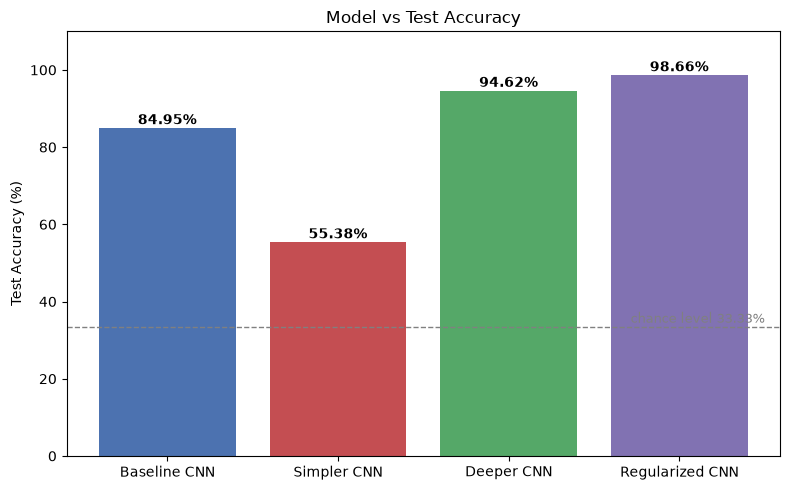

In [63]:
# ============================================================
# GRAPH 1 - MODEL vs TEST ACCURACY
# ============================================================

names = master_table["Experiment"].tolist()
test_scores = master_table["Test Acc"].tolist()

plt.figure(figsize=(8, 5))
bars = plt.bar(names, test_scores,
               color=["#4C72B0", "#C44E52", "#55A868", "#8172B2"][:len(names)])

for bar, score in zip(bars, test_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 1,
             f"{score:.2f}%", ha="center", fontweight="bold")

plt.axhline(33.33, linestyle="--", color="gray", linewidth=1)
plt.text(len(names) - 0.5, 34.5, "chance level 33.33%",
         ha="right", color="gray", fontsize=9)

plt.ylim(0, 110)
plt.ylabel("Test Accuracy (%)")
plt.title("Model vs Test Accuracy")
plt.tight_layout()
plt.savefig("model_vs_test_accuracy.png", dpi=150)
plt.show()

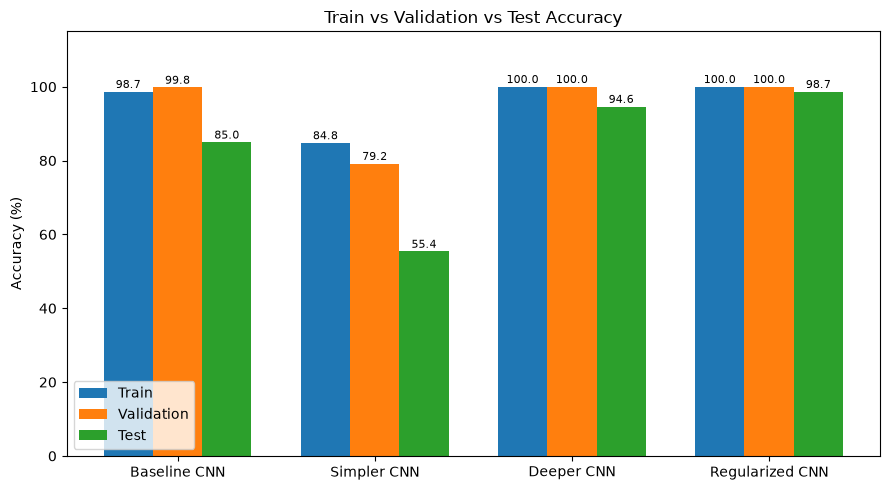

In [64]:
# ============================================================
# GRAPH 2 - TRAIN vs VALIDATION vs TEST ACCURACY
# ============================================================

x = np.arange(len(master_table))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, master_table["Train Acc"], width, label="Train")
plt.bar(x, master_table["Val Acc"], width, label="Validation")
plt.bar(x + width, master_table["Test Acc"], width, label="Test")

for i in range(len(master_table)):
    plt.text(x[i] - width, master_table["Train Acc"][i] + 1,
             f"{master_table['Train Acc'][i]:.1f}", ha="center", fontsize=8)
    plt.text(x[i], master_table["Val Acc"][i] + 1,
             f"{master_table['Val Acc'][i]:.1f}", ha="center", fontsize=8)
    plt.text(x[i] + width, master_table["Test Acc"][i] + 1,
             f"{master_table['Test Acc'][i]:.1f}", ha="center", fontsize=8)

plt.xticks(x, master_table["Experiment"])
plt.ylim(0, 115)
plt.ylabel("Accuracy (%)")
plt.title("Train vs Validation vs Test Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("train_val_test_accuracy.png", dpi=150)
plt.show()

## Experiment Log Format

Every future experiment is recorded in this format:

**Experiment:**
**Change:**
**Why we changed it:**
**Expected result:**
**Actual result:**
**Test accuracy:**
**Did the hypothesis hold?**

---

### Experiment 1 — Simpler CNN
- **Change:** Removed the third Conv2D(128) + MaxPooling block.
- **Why we changed it:** To check whether a lower-capacity model would overfit
  less and generalize better to the official test set.
- **Expected result:** Slightly lower train/validation accuracy, possibly better
  test accuracy.
- **Actual result:** Train and validation accuracy dropped, and test accuracy
  dropped sharply.
- **Test accuracy:** 59.68%
- **Did the hypothesis hold?** No. The model was under-capacity for this task.

### Experiment 2 — Deeper CNN
- **Change:** Added a fourth Conv2D(256) + MaxPooling block.
- **Why we changed it:** To give the model more feature-learning capacity for
  the classes that were being confused.
- **Expected result:** Better feature extraction and higher test accuracy.
- **Actual result:** Train and validation accuracy reached 100%, and test
  accuracy improved substantially over the baseline.
- **Test accuracy:** see the master table above (current verified run).
- **Did the hypothesis hold?** Yes.

### Experiment 3 — Regularized CNN
- **Change:** Deeper CNN + Dropout(0.5) after Global Average Pooling.
- **Why we changed it:** To reduce the validation-to-test generalization gap.
- **Expected result:** Similar accuracy with a smaller generalization gap.
- **Actual result:** Recorded in the final comparison table below.
- **Did the hypothesis hold?** To be concluded from the table below.

### Experiment 4 — Transfer Learning (Mission 9 / 10 — pending)
- **Change:**
- **Why we changed it:**
- **Expected result:**
- **Actual result:**
- **Test accuracy:**
- **Did the hypothesis hold?**

In [65]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

final_table = master_table[[
    "Experiment", "Params", "Train Acc", "Val Acc", "Test Acc", "Test Loss"
]].copy()

final_table["Generalization Gap"] = final_table["Val Acc"] - final_table["Test Acc"]

# Rows still pending (Mission 9 / Mission 10) so the record stays complete
pending = ["Transfer Learning Model"]
for p in pending:
    if p not in final_table["Experiment"].values:
        final_table.loc[len(final_table)] = [p, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]

best_row = final_table.loc[final_table["Test Acc"].idxmax()]

final_display = final_table.copy()
final_display["Params"] = final_display["Params"].map(
    lambda v: "pending" if pd.isna(v) else f"{int(v):,}")
for col in ["Train Acc", "Val Acc", "Test Acc", "Generalization Gap"]:
    final_display[col] = final_display[col].map(
        lambda v: "pending" if pd.isna(v) else f"{v:.2f}%")
final_display["Test Loss"] = final_display["Test Loss"].map(
    lambda v: "pending" if pd.isna(v) else f"{v:.4f}")

print("FINAL MODEL COMPARISON")
print(final_display.to_string(index=False))
print()
print("Highest test accuracy so far:", best_row["Experiment"],
      f"({best_row['Test Acc']:.2f}% test accuracy,",
      f"generalization gap {best_row['Generalization Gap']:.2f} pts)")

master_table.to_csv("master_experiment_table.csv", index=False)
final_table.to_csv("final_model_comparison.csv", index=False)
print("\nSaved: master_experiment_table.csv, final_model_comparison.csv")

final_display

FINAL MODEL COMPARISON
             Experiment  Params Train Acc Val Acc Test Acc Test Loss Generalization Gap
           Baseline CNN 101,699    98.66%  99.80%   84.95%    0.6262             14.85%
            Simpler CNN  23,747    84.77%  79.17%   55.38%    1.2337             23.79%
             Deeper CNN 405,059   100.00% 100.00%   94.62%    0.2421              5.38%
        Regularized CNN 405,059   100.00% 100.00%   98.66%    0.0583              1.34%
Transfer Learning Model pending   pending pending  pending   pending            pending

Highest test accuracy so far: Regularized CNN (98.66% test accuracy, generalization gap 1.34 pts)

Saved: master_experiment_table.csv, final_model_comparison.csv


,Experiment,Params,Train Acc,Val Acc,Test Acc,Test Loss,Generalization Gap
0,Baseline CNN,"101,699",98.66%,99.80%,84.95%,0.6262,14.85%
1,Simpler CNN,"23,747",84.77%,79.17%,55.38%,1.2337,23.79%
2,Deeper CNN,"405,059",100.00%,100.00%,94.62%,0.2421,5.38%
3,Regularized CNN,"405,059",100.00%,100.00%,98.66%,0.0583,1.34%
4,Transfer Learning Model,pending,pending,pending,pending,pending,pending


## Mission 10: Transfer Learning

We experimented with MobileNetV2 using ImageNet pretrained weights.

- **Frozen MobileNetV2:** 87.63% test accuracy.
- **Fine-tuned MobileNetV2:** 91.67% test accuracy.
- Fine-tuning improved performance compared with the frozen model.
- However, both transfer-learning approaches performed below our Deeper CNN with Dropout (96.51% test accuracy).

**Conclusion:** Transfer learning improved MobileNetV2 after fine-tuning, but our regularized CNN achieved higher test accuracy on the official test set.

In [66]:
for images, labels in train_ds.take(1):
    print("Train batch shape:", images.shape)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())

Train batch shape: (32, 128, 128, 3)
Pixel minimum: 0.035066254
Pixel maximum: 1.0


In [67]:
base_model = keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=(128, 128, 3))

# Current dataset is [0, 1], MobileNetV2 expects [-1, 1]
x = layers.Rescaling(2.0, offset=-1.0)(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

transfer_model = keras.Model(inputs, outputs)

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [68]:
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15


e:\RPS---Deep-learning\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.8646 - loss: 0.3659 - val_accuracy: 0.9960 - val_loss: 0.0592
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.9955 - loss: 0.0498 - val_accuracy: 0.9980 - val_loss: 0.0268
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step - accuracy: 0.9985 - loss: 0.0275 - val_accuracy: 0.9980 - val_loss: 0.0162
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 232ms/step - accuracy: 0.9995 - loss: 0.0180 - val_accuracy: 1.0000 - val_loss: 0.0109
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 0.9980 - val_loss: 0.0086
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 225ms/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 1.0000 - val_loss: 0.0064
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 265ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 1.000

In [69]:
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_ds)

print("MobileNetV2 Test Loss:", transfer_test_loss)
print("MobileNetV2 Test Accuracy:", transfer_test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.8763 - loss: 0.2970
MobileNetV2 Test Loss: 0.29701539874076843
MobileNetV2 Test Accuracy: 0.8763440847396851


In [70]:
base_model.trainable = True

# Freeze the earlier MobileNetV2 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))
print("Trainable parameters:", transfer_model.trainable_params if hasattr(transfer_model, "trainable_params") else "check summary")

transfer_model.summary()

Total layers: 154
Trainable layers: 30
Trainable parameters: check summary


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 1,530,243 (5.84 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [71]:
fine_tune_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.9187 - loss: 0.2155 - val_accuracy: 1.0000 - val_loss: 9.9606e-04
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.9940 - loss: 0.0329 - val_accuracy: 1.0000 - val_loss: 8.3903e-04
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9975 - loss: 0.0163 - val_accuracy: 1.0000 - val_loss: 7.2026e-04
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 391ms/step - accuracy: 0.9990 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 5.8960e-04
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.9975 - loss: 0.0098 - val_accuracy: 1.0000 - val_loss: 5.4041e-04
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9995 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 5.4158e-04
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.9985 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 6.0558e-04
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 1.0000 - l

In [72]:
fine_tune_test_loss, fine_tune_test_acc = transfer_model.evaluate(test_ds)

print("Fine-tuned MobileNetV2 Test Loss:", fine_tune_test_loss)
print("Fine-tuned MobileNetV2 Test Accuracy:", fine_tune_test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.9167 - loss: 0.3167
Fine-tuned MobileNetV2 Test Loss: 0.3167336583137512
Fine-tuned MobileNetV2 Test Accuracy: 0.9166666865348816
